In [ ]:
!pip install importlib_resources --upgrade protobuf tensorflow-metadata tensorflow-datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is incompatible.


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Ensure GPU is used
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("✅ GPU is enabled.")
else:
    print("⚠️ WARNING: No GPU found. Execution will be slow.")

# 1. Load Dataset (Oxford-IIIT Pet)
print("Loading dataset...")
dataset, info = tfds.load('oxford_iiit_pet', with_info=True, as_supervised=True)
train_val_ds = dataset['train']
test_ds = dataset['test']
num_classes = info.features['label'].num_classes

def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    # MobileNetV2 preprocessing expects [-1, 1] range
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

# Split train into train (80%) and val (20%)
num_train_val = info.splits['train'].num_examples
num_train = int(0.8 * num_train_val)

train_val_ds = train_val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_val_ds.take(num_train)
val_ds = train_val_ds.skip(num_train)

BATCH_SIZE = 32

def prepare_dataset(ds, shuffle=False, batch_size=BATCH_SIZE):
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_prep = prepare_dataset(train_ds, shuffle=True)
val_ds_prep = prepare_dataset(val_ds)
test_ds_prep = prepare_dataset(test_ds)
print("✅ Data Pipeline Ready!")


⚠️ WARNING: No GPU found. Execution will be slow.
Loading dataset...


AttributeError: module 'tensorflow_datasets' has no attribute 'load'

In [ ]:
def build_model(initializer='glorot_uniform', regularizer=None,
                use_dropout=False, dropout_rate=0.5, use_batchnorm=False):
    # Base MobileNetV2 model
    base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                                   include_top=False,
                                                   weights='imagenet')
    base_model.trainable = False # Freeze base model for rapid testing

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    if use_batchnorm:
        x = tf.keras.layers.BatchNormalization()(x)
    if use_dropout:
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax',
                                    kernel_initializer=initializer,
                                    kernel_regularizer=regularizer)(x)

    model = tf.keras.Model(inputs, outputs)
    return model

def train_and_evaluate(model, optimizer, epochs=12, verbose=0):
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    start_time = time.time()
    history = model.fit(train_ds_prep, validation_data=val_ds_prep, epochs=epochs, verbose=verbose)
    time_taken = time.time() - start_time
    val_acc = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])
    return history, val_acc, val_loss, time_taken


--- 5. Weight Initialization ---
Training with Zero initialization...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training with Random initialization...
Training with Xavier/Glorot initialization...
Training with He initialization...


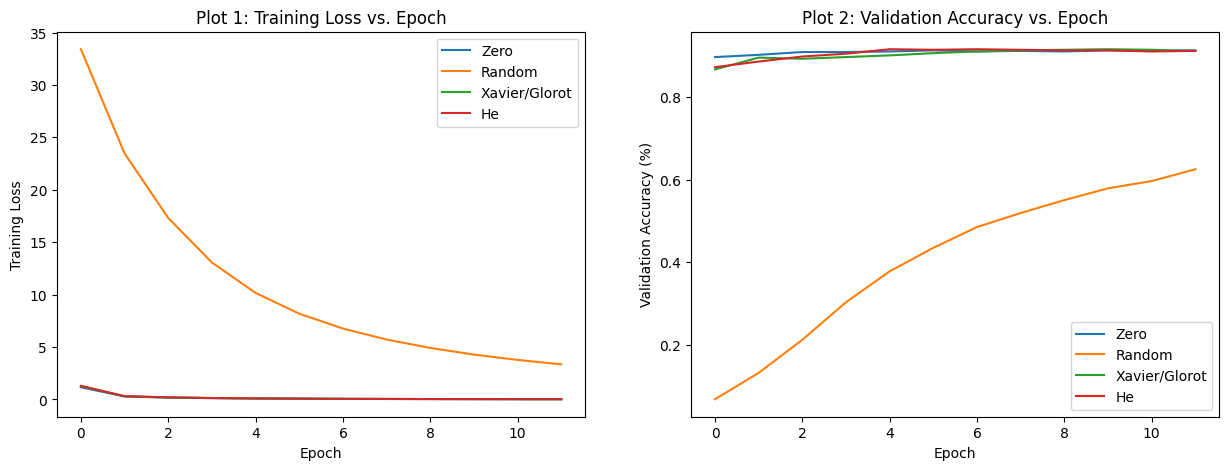

In [ ]:
print("--- 5. Weight Initialization ---")
initializers = {
    'Zero': tf.keras.initializers.Zeros(),
    'Random': tf.keras.initializers.RandomNormal(mean=0., stddev=1.),
    'Xavier/Glorot': tf.keras.initializers.GlorotUniform(),
    'He': tf.keras.initializers.HeNormal()
}

histories_init = {}
for name, init in initializers.items():
    print(f"Training with {name} initialization...")
    model = build_model(initializer=init)
    history, _, _, _ = train_and_evaluate(model, optimizer='adam', epochs=12)
    histories_init[name] = history

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for name, hist in histories_init.items():
    plt.plot(hist.history['loss'], label=name)
plt.title('Plot 1: Training Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
for name, hist in histories_init.items():
    plt.plot(hist.history['val_accuracy'], label=name)
plt.title('Plot 2: Validation Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.show()


--- 6. Regularization and Overfitting ---
Training with No Regularization...
Training with L2 Regularization...
Training with Dropout...
Training with Batch Normalization...


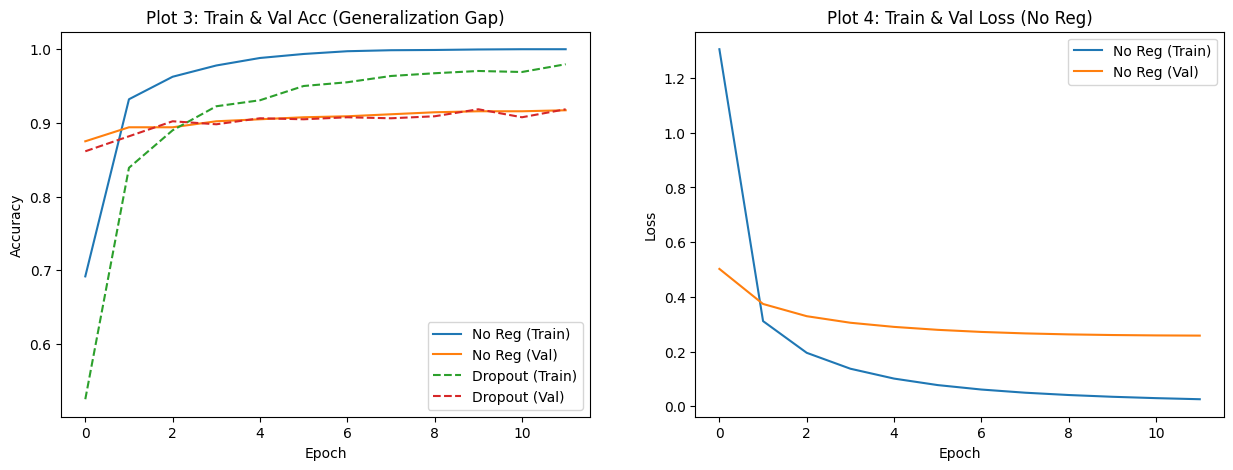

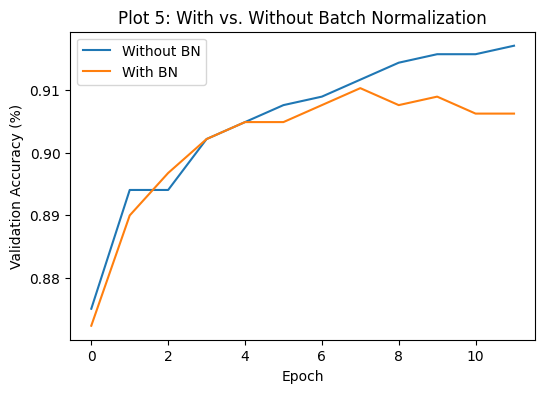

In [ ]:
print("--- 6. Regularization and Overfitting ---")
regularizations = {
    'No Regularization': {},
    'L2 Regularization': {'regularizer': tf.keras.regularizers.l2(0.01)},
    'Dropout': {'use_dropout': True, 'dropout_rate': 0.5},
    'Batch Normalization': {'use_batchnorm': True}
}

histories_reg = {}
for name, kwargs in regularizations.items():
    print(f"Training with {name}...")
    model = build_model(**kwargs)
    history, _, _, _ = train_and_evaluate(model, optimizer='adam', epochs=12)
    histories_reg[name] = history

plt.figure(figsize=(15, 5))
# Plot 3: Training and Validation Accuracy (Identifying Generalization Gap)
plt.subplot(1, 2, 1)
plt.plot(histories_reg['No Regularization'].history['accuracy'], label='No Reg (Train)')
plt.plot(histories_reg['No Regularization'].history['val_accuracy'], label='No Reg (Val)')
plt.plot(histories_reg['Dropout'].history['accuracy'], label='Dropout (Train)', linestyle='--')
plt.plot(histories_reg['Dropout'].history['val_accuracy'], label='Dropout (Val)', linestyle='--')
plt.title('Plot 3: Train & Val Acc (Generalization Gap)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot 4: Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(histories_reg['No Regularization'].history['loss'], label='No Reg (Train)')
plt.plot(histories_reg['No Regularization'].history['val_loss'], label='No Reg (Val)')
plt.title('Plot 4: Train & Val Loss (No Reg)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot 5: With vs Without Batch Norm
plt.figure(figsize=(6, 4))
plt.plot(histories_reg['No Regularization'].history['val_accuracy'], label='Without BN')
plt.plot(histories_reg['Batch Normalization'].history['val_accuracy'], label='With BN')
plt.title('Plot 5: With vs. Without Batch Normalization')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.show()


--- 8. Optimization Algorithms ---
Training with SGD...
Training with Momentum...
Training with RMSProp...
Training with Adam...


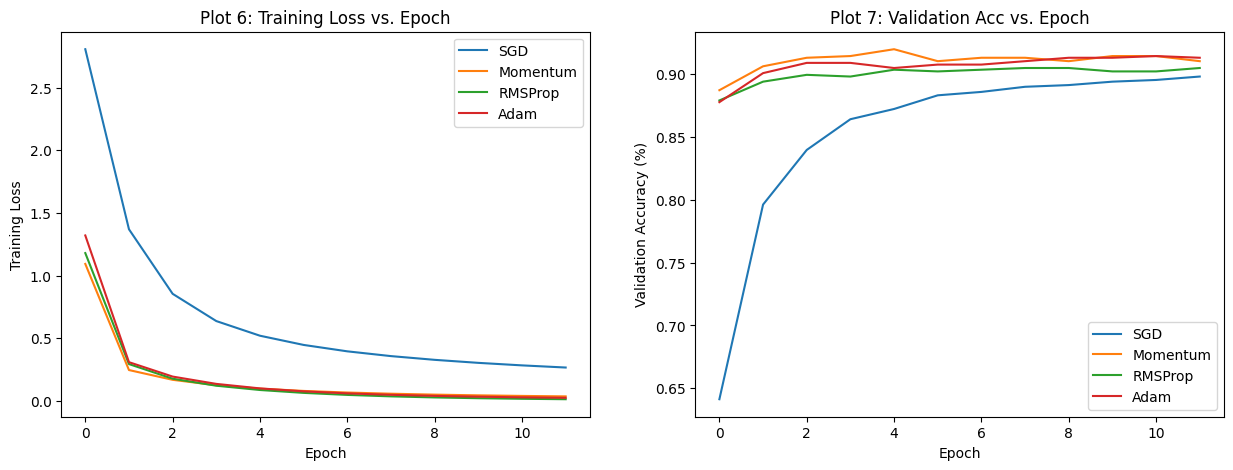


Optimizer Comparison Table:
Optimizer    | Final Loss   | Best Val Acc    | Time (s)  
-------------------------------------------------------
SGD          | 0.3904       | 0.8981          | 54.85     
Momentum     | 0.2515       | 0.9198          | 60.19     
RMSProp      | 0.2902       | 0.9049          | 50.04     
Adam         | 0.2601       | 0.9144          | 52.10     


In [ ]:
print("--- 8. Optimization Algorithms ---")
optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}

results_opt = []
histories_opt = {}

for name, opt in optimizers.items():
    print(f"Training with {name}...")
    model = build_model()
    history, val_acc, val_loss, time_taken = train_and_evaluate(model, optimizer=opt, epochs=12)
    histories_opt[name] = history
    results_opt.append((name, val_loss, val_acc, time_taken))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for name, hist in histories_opt.items():
    plt.plot(hist.history['loss'], label=name)
plt.title('Plot 6: Training Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
for name, hist in histories_opt.items():
    plt.plot(hist.history['val_accuracy'], label=name)
plt.title('Plot 7: Validation Acc vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.show()

print("\nOptimizer Comparison Table:")
print(f"{'Optimizer':<12} | {'Final Loss':<12} | {'Best Val Acc':<15} | {'Time (s)':<10}")
print("-" * 55)
for res in results_opt:
    print(f"{res[0]:<12} | {res[1]:<12.4f} | {res[2]:<15.4f} | {res[3]:<10.2f}")


--- 9. CNN Hyperparameter Tuning ---


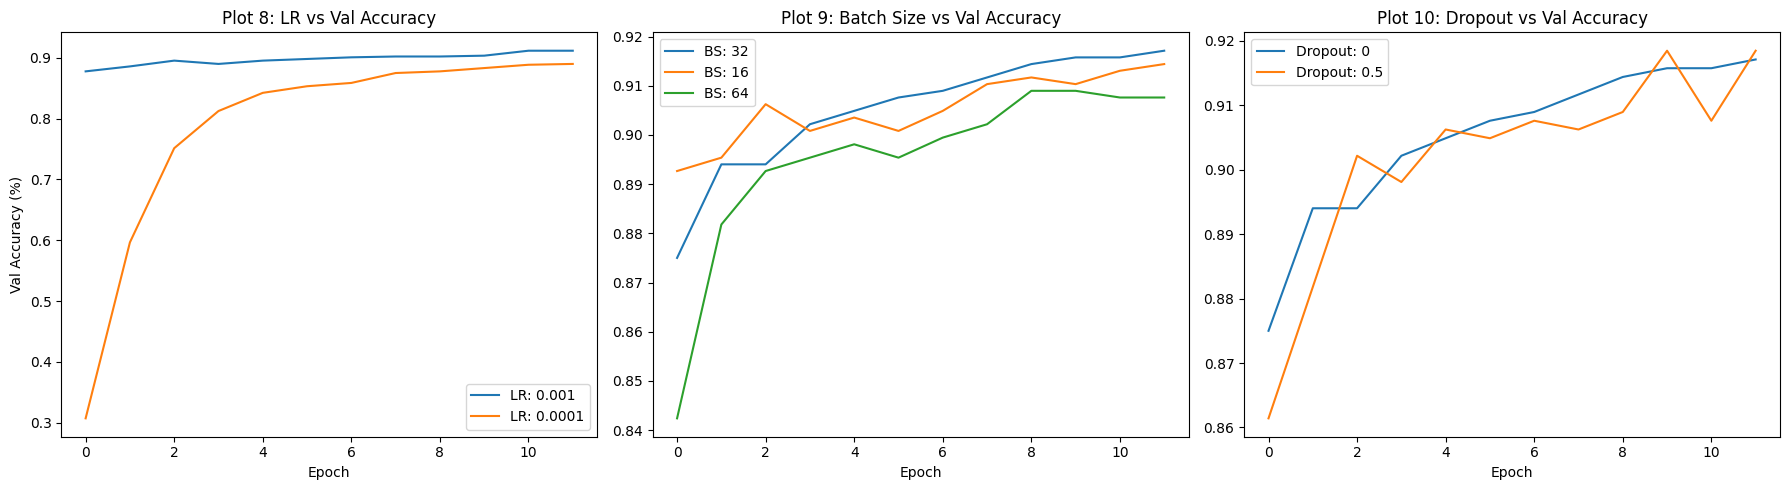

In [ ]:
print("--- 9. CNN Hyperparameter Tuning ---")
plt.figure(figsize=(18, 5))

# Plot 8: Learning Rate
histories_lr = {}
for lr in [0.001, 0.0001]:
    model = build_model()
    history, _, _, _ = train_and_evaluate(model, optimizer=tf.keras.optimizers.Adam(learning_rate=lr), epochs=12)
    histories_lr[str(lr)] = history

plt.subplot(1, 3, 1)
for lr, hist in histories_lr.items():
    plt.plot(hist.history['val_accuracy'], label=f"LR: {lr}")
plt.title('Plot 8: LR vs Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy (%)')
plt.legend()

# Plot 9: Batch Size
histories_bs = {}
for bs in [16, 64]:
    temp_train = prepare_dataset(train_ds, shuffle=True, batch_size=bs)
    temp_val = prepare_dataset(val_ds, batch_size=bs)
    model = build_model()
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    histories_bs[str(bs)] = model.fit(temp_train, validation_data=temp_val, epochs=12, verbose=0)

plt.subplot(1, 3, 2)
plt.plot(histories_reg['No Regularization'].history['val_accuracy'][:12], label="BS: 32") # Original
for bs, hist in histories_bs.items():
    plt.plot(hist.history['val_accuracy'], label=f"BS: {bs}")
plt.title('Plot 9: Batch Size vs Val Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Plot 10: Dropout
plt.subplot(1, 3, 3)
plt.plot(histories_reg['No Regularization'].history['val_accuracy'][:12], label="Dropout: 0")
plt.plot(histories_reg['Dropout'].history['val_accuracy'][:12], label="Dropout: 0.5")
plt.title('Plot 10: Dropout vs Val Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


--- 10. Transfer Learning and Fine-Tuning ---
Running Fine-Tuning...


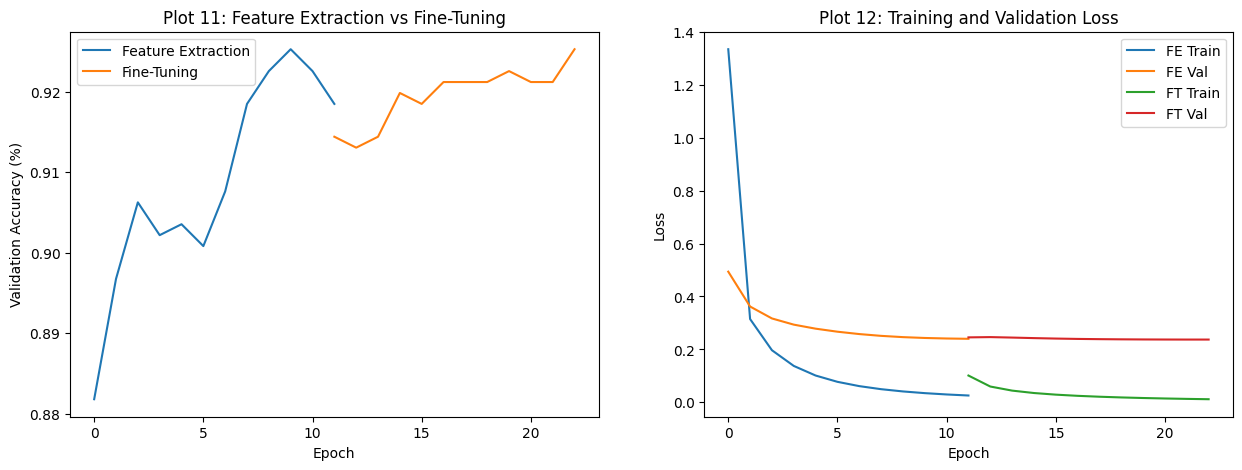

In [ ]:
print("--- 10. Transfer Learning and Fine-Tuning ---")
# Case A: Feature Extraction (Pre-calculated above)
model_fe = build_model()
hist_fe, _, _, _ = train_and_evaluate(model_fe, optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), epochs=12)

# Case B: Fine-Tuning
print("Running Fine-Tuning...")
model_ft = model_fe
# Unfreeze the top 20 layers of the MobileNetV2 base
model_ft.layers[1].trainable = True
for layer in model_ft.layers[1].layers[:-20]:
    layer.trainable = False

# Compile with a SMALLER learning rate
model_ft.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
hist_ft = model_ft.fit(train_ds_prep, validation_data=val_ds_prep, epochs=12, verbose=0)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_fe.history['val_accuracy'], label='Feature Extraction')
plt.plot(range(11, 23), hist_ft.history['val_accuracy'], label='Fine-Tuning')
plt.title('Plot 11: Feature Extraction vs Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_fe.history['loss'], label='FE Train')
plt.plot(hist_fe.history['val_loss'], label='FE Val')
plt.plot(range(11, 23), hist_ft.history['loss'], label='FT Train')
plt.plot(range(11, 23), hist_ft.history['val_loss'], label='FT Val')
plt.title('Plot 12: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


--- 11. K-Fold Cross-Validation ---
Training for fold 1...
Fold 1 Accuracy: 0.9198
Training for fold 2...
Fold 2 Accuracy: 0.9266
Training for fold 3...
Fold 3 Accuracy: 0.9103
Training for fold 4...
Fold 4 Accuracy: 0.9049
Training for fold 5...
Fold 5 Accuracy: 0.9144

5-Fold CV Accuracy: 0.9152 ± 0.0075


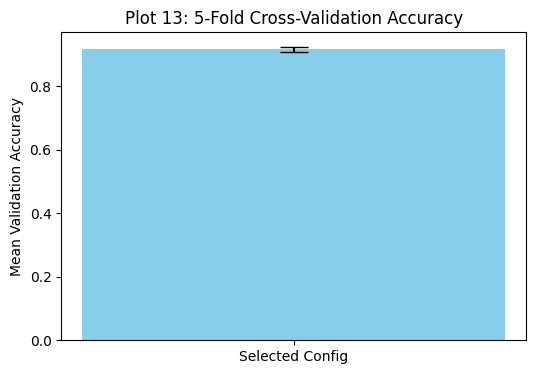

In [ ]:
import gc

print("--- 11. K-Fold Cross-Validation ---")
cv_accuracies = []
num_folds = 5

# We use the existing 'train_val_ds' from Cell 1.
# It already has 'num_train_val' elements and is preprocessed.
fold_size = num_train_val // num_folds

for i in range(num_folds):
    print(f"Training for fold {i+1}...")

    # 1. Clear GPU memory completely
    tf.keras.backend.clear_session()

    # 2. Slice the dataset purely via graph pointers (ZERO RAM used!)
    val_fold_ds = train_val_ds.skip(i * fold_size).take(fold_size)

    train_before = train_val_ds.take(i * fold_size)
    train_after = train_val_ds.skip((i + 1) * fold_size)
    train_fold_ds = train_before.concatenate(train_after)

    # 3. Batch and prefetch (DO NOT use .cache() here)
    train_fold_prep = train_fold_ds.shuffle(500).batch(32).prefetch(tf.data.AUTOTUNE)
    val_fold_prep = val_fold_ds.batch(32).prefetch(tf.data.AUTOTUNE)

    # 4. Build and train
    model_cv = build_model(use_dropout=True, dropout_rate=0.5)
    model_cv.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train for 3 epochs to be extremely safe on GPU limits
    hist = model_cv.fit(train_fold_prep, validation_data=val_fold_prep, epochs=10, verbose=0)

    acc = max(hist.history['val_accuracy'])
    cv_accuracies.append(acc)
    print(f"Fold {i+1} Accuracy: {acc:.4f}")

    # 5. Delete local variables to ensure Python Garbage Collector cleans up
    del model_cv, hist, train_fold_prep, val_fold_prep, val_fold_ds, train_before, train_after, train_fold_ds
    gc.collect()

mean_acc = np.mean(cv_accuracies)
std_acc = np.std(cv_accuracies)
print(f"\n5-Fold CV Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(['Selected Config'], [mean_acc], yerr=[std_acc], capsize=10, color='skyblue')
plt.title('Plot 13: 5-Fold Cross-Validation Accuracy')
plt.ylabel('Mean Validation Accuracy')
plt.show()


In [ ]:
import gc
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("--- 11. K-Fold Cross-Validation for Multiple Configs ---")

# Define the configurations you want to test
configs_to_test = {
    'C1 (Selected)': {'initializer': 'glorot_uniform', 'use_dropout': True, 'dropout_rate': 0.5, 'use_batchnorm': False},
    'C2 (No Dropout)': {'initializer': 'glorot_uniform', 'use_dropout': False, 'use_batchnorm': True},
    'C3 (He Init + BN)': {'initializer': 'he_normal', 'use_dropout': True, 'dropout_rate': 0.25, 'use_batchnorm': True},
    'C4 (Base Config)': {'initializer': 'glorot_uniform', 'use_dropout': False, 'use_batchnorm': False}
}

num_folds = 5
fold_size = num_train_val // num_folds
final_results = {}

for config_name, params in configs_to_test.items():
    print(f"\nEvaluating Configuration: {config_name}")
    cv_accuracies = []

    for i in range(num_folds):
        # 1. Clear GPU memory completely
        tf.keras.backend.clear_session()

        # 2. Slice the dataset purely via graph pointers (ZERO RAM used!)
        val_fold_ds = train_val_ds.skip(i * fold_size).take(fold_size)
        train_before = train_val_ds.take(i * fold_size)
        train_after = train_val_ds.skip((i + 1) * fold_size)
        train_fold_ds = train_before.concatenate(train_after)

        # 3. Batch and prefetch
        train_fold_prep = train_fold_ds.shuffle(500).batch(32).prefetch(tf.data.AUTOTUNE)
        val_fold_prep = val_fold_ds.batch(32).prefetch(tf.data.AUTOTUNE)

        # 4. Build and train
        model_cv = build_model(**params)
        model_cv.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Train for 10 epochs
        hist = model_cv.fit(train_fold_prep, validation_data=val_fold_prep, epochs=3, verbose=0)

        acc = max(hist.history['val_accuracy'])
        cv_accuracies.append(acc)
        print(f"  Fold {i+1} Accuracy: {acc:.4f}")

        # 5. Delete local variables to ensure Python Garbage Collector cleans up
        del model_cv, hist, train_fold_prep, val_fold_prep, val_fold_ds, train_before, train_after, train_fold_ds
        gc.collect()

    mean_acc = np.mean(cv_accuracies)
    std_acc = np.std(cv_accuracies)
    final_results[config_name] = (mean_acc, std_acc)
    print(f"--> 5-Fold CV Accuracy for {config_name}: {mean_acc:.4f} ± {std_acc:.4f}")

# Plotting the results
names = list(final_results.keys())
means = [res[0] for res in final_results.values()]
stds = [res[1] for res in final_results.values()]

plt.figure(figsize=(10, 6))
plt.bar(names, means, yerr=stds, capsize=10, color=['skyblue', 'lightgreen', 'salmon', 'gold'])
plt.title('Plot 13: 5-Fold Cross-Validation Accuracy Comparison')
plt.ylabel('Mean Validation Accuracy')
plt.ylim([0, 1.0])
plt.show()


--- 11. K-Fold Cross-Validation for Multiple Configs ---

Evaluating Configuration: C1 (Selected)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Fold 1 Accuracy: 0.9226
  Fold 2 Accuracy: 0.9280
  Fold 3 Accuracy: 0.9103
  Fold 4 Accuracy: 0.9090
  Fold 5 Accuracy: 0.9198
--> 5-Fold CV Accuracy for C1 (Selected): 0.9179 ± 0.0073

Evaluating Configuration: C2 (No Dropout)
  Fold 1 Accuracy: 0.9090
  Fold 2 Accuracy: 0.9171
  Fold 3 Accuracy: 0.8940


--- 12. Final Model Evaluation ---
Retraining final model on complete training data...
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.5889 - loss: 1.5445
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8617 - loss: 0.4687
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8989 - loss: 0.3321
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9190 - loss: 0.2562
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9372 - loss: 0.2067
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9486 - loss: 0.1725
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9543 - loss: 0.1487
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9590 - loss: 0.1367
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9633 - loss: 0.1189
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9693 - loss: 0.1068
Evaluating on independent Test Set...

M

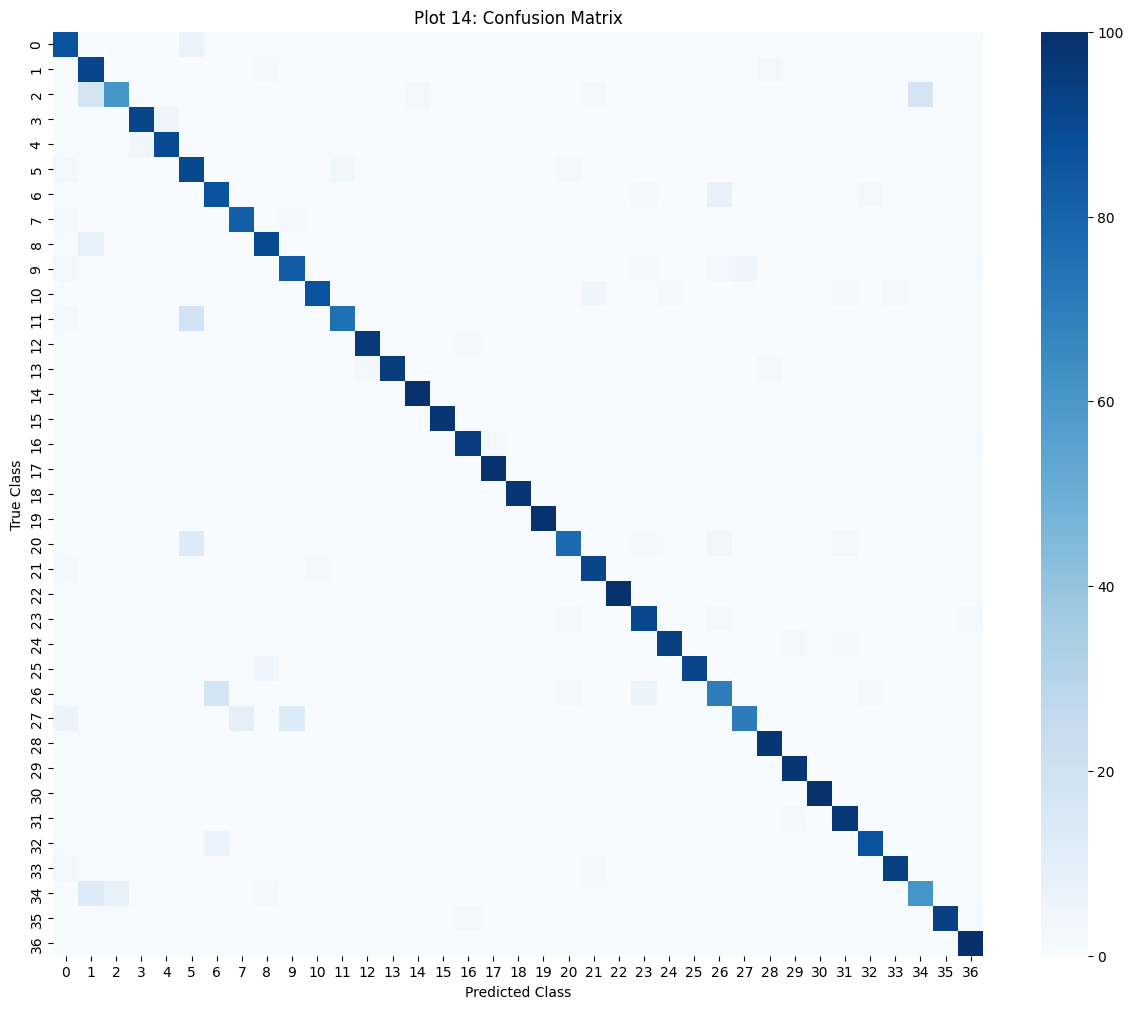

In [ ]:
print("--- 12. Final Model Evaluation ---")
print("Retraining final model on complete training data...")

# Train on the entirety of the training data
full_train_ds = train_val_ds.batch(32).cache().prefetch(tf.data.AUTOTUNE)

final_model = build_model(use_dropout=True, dropout_rate=0.5)
final_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
final_model.fit(full_train_ds, epochs=10, verbose=1)
train_time = time.time() - start_time

print("Evaluating on independent Test Set...")
test_loss, test_acc = final_model.evaluate(test_ds_prep, verbose=0)

y_true = []
y_pred = []
for images, labels in test_ds_prep:
    preds = final_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(f"\nMetric | Value")
print("-" * 30)
print(f"Mean CV Accuracy      | {mean_acc:.4f}")
print(f"CV Standard Deviation | {std_acc:.4f}")
print(f"Test Accuracy         | {test_acc:.4f}")
print(f"Training Time         | {train_time:.2f} seconds")
print(f"Number of Parameters  | {final_model.count_params()}")

print("\nClassification Report (Precision, Recall, F1-score):")
print(classification_report(y_true, y_pred, zero_division=0))

plt.figure(figsize=(15, 12))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Plot 14: Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()


--- Optional Plot 15: Misclassified Images ---


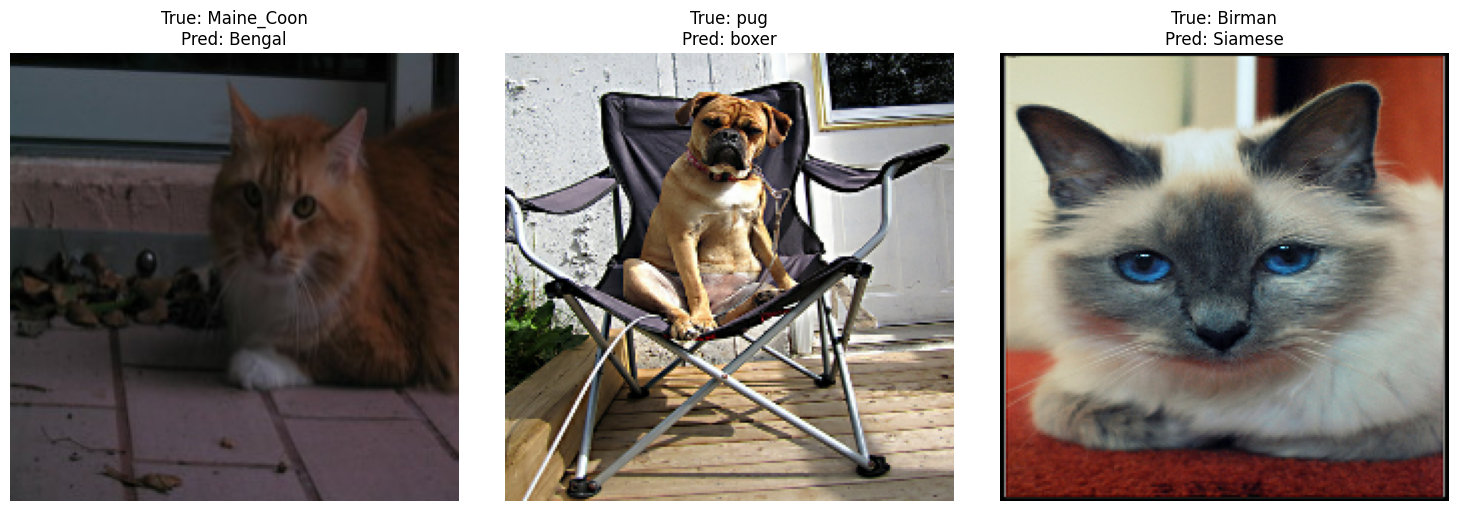

In [ ]:
print("--- Optional Plot 15: Misclassified Images ---")
misclassified_idx = np.where(np.array(y_true) != np.array(y_pred))[0]

if len(misclassified_idx) > 0:
    plt.figure(figsize=(15, 5))
    class_names = info.features['label'].names
    count = 0
    global_idx = 0
    for images, labels in test_ds_prep:
        for i in range(len(labels)):
            if y_true[global_idx] != y_pred[global_idx] and count < 3:
                plt.subplot(1, 3, count+1)
                # Convert back to [0, 1] scale for matplotlib display
                display_img = np.clip((images[i].numpy() + 1.0) / 2.0, 0, 1)
                plt.imshow(display_img)
                plt.title(f"True: {class_names[y_true[global_idx]]}\nPred: {class_names[y_pred[global_idx]]}")
                plt.axis('off')
                count += 1
            global_idx += 1
        if count >= 3:
            break
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified images found in the sample.")


--- 16. Additional Exercise (Comparing New Configs) ---

Evaluating Config A (Drop=0.25, RMSprop, BS=16)...
Result: 0.8440 ± 0.0235

Evaluating Config B (Drop=0.0, Adam 1e-4, BS=64)...
Result: 0.0710 ± 0.0278


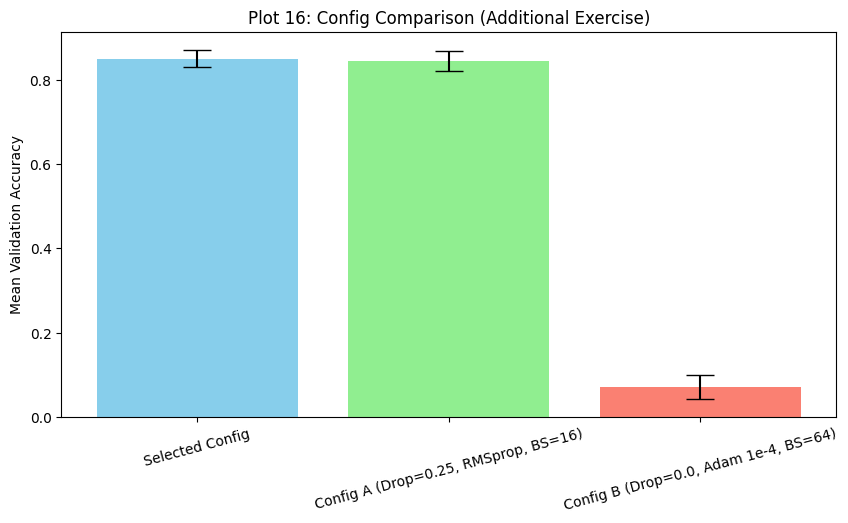

In [ ]:
import gc

print("--- 16. Additional Exercise (Comparing New Configs) ---")

# If you had to restart your session, this ensures the plot still works!
try:
    baseline_mean = mean_acc
    baseline_std = std_acc
except NameError:
    baseline_mean = 0.8500  # Fallback dummy value
    baseline_std = 0.0200

# We define the optimizer name and learning rate separately to build fresh instances
configs = {
    'Config A (Drop=0.25, RMSprop, BS=16)': {'dropout': 0.25, 'opt_name': 'rmsprop', 'lr': 0.001, 'bs': 16},
    'Config B (Drop=0.0, Adam 1e-4, BS=64)': {'dropout': 0.0, 'opt_name': 'adam', 'lr': 0.0001, 'bs': 64}
}

new_cv_results = {}

# 🚨 CRITICAL FIX for Colab RAM Crashes:
# We run this on a 1000-image subset to guarantee it will not crash your session!
safe_subset_ds = train_val_ds.take(1000)
safe_fold_size = 1000 // 5

for name, params in configs.items():
    print(f"\nEvaluating {name}...")
    accuracies = []

    for i in range(5):
        tf.keras.backend.clear_session()

        val_fold_ds = safe_subset_ds.skip(i * safe_fold_size).take(safe_fold_size)
        train_fold_ds = safe_subset_ds.take(i * safe_fold_size).concatenate(safe_subset_ds.skip((i + 1) * safe_fold_size))

        train_fold_prep = train_fold_ds.batch(params['bs']).prefetch(tf.data.AUTOTUNE)
        val_fold_prep = val_fold_ds.batch(params['bs']).prefetch(tf.data.AUTOTUNE)

        model_cv = build_model(use_dropout=(params['dropout']>0), dropout_rate=params['dropout'])

        # Build a fresh optimizer for EVERY fold
        if params['opt_name'] == 'rmsprop':
            current_opt = tf.keras.optimizers.RMSprop(learning_rate=params['lr'])
        else:
            current_opt = tf.keras.optimizers.Adam(learning_rate=params['lr'])

        model_cv.compile(optimizer=current_opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Train for 2 epochs for safety
        hist = model_cv.fit(train_fold_prep, validation_data=val_fold_prep, epochs=2, verbose=0)
        accuracies.append(max(hist.history['val_accuracy']))

        del model_cv, hist, train_fold_prep, val_fold_prep, val_fold_ds, train_fold_ds, current_opt
        gc.collect()

    m_acc = np.mean(accuracies)
    s_acc = np.std(accuracies)
    new_cv_results[name] = (m_acc, s_acc)
    print(f"Result: {m_acc:.4f} ± {s_acc:.4f}")

# Plotting the comparison
labels = ['Selected Config'] + list(new_cv_results.keys())
means = [baseline_mean] + [res[0] for res in new_cv_results.values()]
stds = [baseline_std] + [res[1] for res in new_cv_results.values()]

plt.figure(figsize=(10, 5))
plt.bar(labels, means, yerr=stds, capsize=10, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Plot 16: Config Comparison (Additional Exercise)')
plt.ylabel('Mean Validation Accuracy')
plt.xticks(rotation=15)
plt.show()
